# 🧬 AMBER Multi-Replica Trajectory Convergence Analysis

**Purpose**: Analyze convergence of MD simulations using Clustering Ensemble Similarity (CES) across multiple replicas.

**Systems**: PSY-FSPP, PSY-GGPP, CrtM-FSPP, CrtM-GGPP

**Input**: AMBER `.prmtop` + `.nc` trajectories

**Output**: Convergence plots + pickled results

---
*Adapted from MDAnalysis ENCORE examples*

In [1]:
# %% [markdown]
# ## 📦 Imports & Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import encore, align
from MDAnalysis.analysis.encore.clustering import ClusteringMethod as clm
from MDAnalysis.analysis.encore.dimensionality_reduction import DimensionalityReductionMethod as drm
from pathlib import Path
import warnings, pickle
warnings.filterwarnings('ignore')
from tqdm import tqdm

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

/home/dlbox/miniconda3/lib/python3.12/site-packages/MDAnalysis/lib/pkdtree.py:33: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.spatial import cKDTree
/home/dlbox/miniconda3/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
/home/dlbox/miniconda3/lib/python3.12/site-packages/MDAnalysis/analysis/encore/__init__.py:45: DeprecationWarning: Deprecation in version 2.8.0
MDAnalysis.analysis.encore is deprecated in favour of the MDAKit mdaencore (https://www.mdanalysis.org/mdaencore/) and will be removed in MDAnalysis ve

In [3]:
# %% [markdown]
# ## 🔧 AMBER Mask → MDAnalysis Selection Converter

In [4]:
def amber_mask_to_mda(amber_mask: str) -> str:
    """
    Convert AMBER-style mask to MDAnalysis selection string.
    
    Examples:
        ":1-300@CA" → "resid 1-300 and name CA"
        ":10,20,30@CA,C" → "(resid 10 20 30) and (name CA C)"
    """
    if not amber_mask:
        return "protein and name CA"
    
    if '@' in amber_mask:
        res_part, atom_part = amber_mask.split('@')
    else:
        res_part, atom_part = amber_mask, "CA"
    
    res_part = res_part.strip(':')
    if ',' in res_part:
        if res_part[0].isdigit():
            resid_list = ' '.join(res_part.split(','))
            res_sel = f"resid {resid_list}"
        else:
            resname_list = ' '.join(res_part.split(','))
            res_sel = f"resname {resname_list}"
    elif '-' in res_part and not res_part[0].isalpha():
        start, end = res_part.split('-')
        res_sel = f"resid {start}-{end}"
    else:
        if res_part.isdigit():
            res_sel = f"resid {res_part}"
        else:
            res_sel = f"resname {res_part}"
    
    atom_part = atom_part.strip()
    if ',' in atom_part:
        atom_list = ' '.join(atom_part.split(','))
        atom_sel = f"name {atom_list}"
    else:
        atom_sel = f"name {atom_part}"
    
    return f"({res_sel}) and ({atom_sel})"

# Test
print(f"Test: ':1-300@CA' → '{amber_mask_to_mda(':1-300@CA')}'")

Test: ':1-300@CA' → '(resid 1-300) and (name CA)'


In [5]:
# %% [markdown]
# ## 🗂️ System Configuration

In [6]:
SYSTEMS = {
    "PSY-FSPP": {
        "root_dir": "/media/dlbox/6TB/OPENFOLD/with_FPP2/run/",
        "replica_folders": ["MD", "MD2", "MD3"],
        "traj_filename": "MMPBSA/center2x.nc",
        "top_file": "MD/solvated.prmtop",
        "amber_ca_mask": ":1-300@CA",
        "color": "#2E86AB",
    },
    "PSY-GGPP": {
        "root_dir": "/media/dlbox/6TB/OPENFOLD/run/",
        "replica_folders": ["MD", "MD2", "MD3"],
        "traj_filename": "MMPBSA/center2x.nc",
        "top_file": "MD/solvated.prmtop",
        "amber_ca_mask": ":1-300@CA",
        "color": "#A23B72",
    },
    "CrtM-FSPP": {
        "root_dir": "/media/dlbox/8TB/New_simulation/PQR/3w7f/run/",
        "replica_folders": ["MD", "MD2", "MD3"],
        "traj_filename": "MMPBSA/center2x.nc",
        "top_file": "MD/solvated.prmtop",
        "amber_ca_mask": ":1-284@CA",
        "color": "#18B0B0",
    },
    "CrtM-GGPP": {
        "root_dir": "/media/dlbox/8TB/New_simulation/PQR/3w7f/with_GGPP/run/",
        "replica_folders": ["MD", "MD2", "MD3"],
        "traj_filename": "MMPBSA/center2x.nc",
        "top_file": "MD/solvated.prmtop",
        "amber_ca_mask": ":1-284@CA",
        "color": "#F18F01",
    },
}

In [7]:
# %% [markdown]
# ## 🔄 Load & Preprocess Replica Function

In [8]:
def load_replica_universe(root_dir: str, replica_folder: str, 
                         traj_filename: str, top_file: str,
                         amber_mask: str, stride: int = 1):
    """Load a single AMBER replica trajectory with alignment."""
    root = Path(root_dir)
    top_path = root / top_file
    traj_path = root / replica_folder / traj_filename
    
    if not top_path.exists():
        print(f"⚠️ Topology not found: {top_path}")
        return None
    if not traj_path.exists():
        print(f"⚠️ Trajectory not found: {traj_path}")
        return None
    
    try:
        u = mda.Universe(str(top_path), str(traj_path))
        selection_str = amber_mask_to_mda(amber_mask)
        selected_atoms = u.select_atoms(selection_str)
        
        if len(selected_atoms) == 0:
            print(f"⚠️ No atoms selected with mask '{amber_mask}'")
            return None
        
        # Align to first frame
        aligner = align.AlignTraj(u, u, select=selection_str, 
                                 in_memory=True, verbose=False)
        aligner.run()
        
        if stride > 1:
            u.trajectory[::stride]
        
        return u, selection_str
        
    except Exception as e:
        print(f"❌ Error loading {replica_folder}: {e}")
        return None

In [9]:
# %% [markdown]
# ## 📊 Convergence Analysis Function

In [10]:
def analyze_system_convergence(system_name: str, config: dict, 
                              window_size: int = 50, 
                              stride: int = 1,
                              clustering_kwargs: dict = None):
    """Run CES convergence analysis across all replicas of a system."""
    if clustering_kwargs is None:
        clustering_kwargs = {'n_clusters': 10, 'init': 'k-means++', 'algorithm': 'auto'}
    
    results = {
        'ces_data': [],
        'replica_names': [],
        'n_frames': [],
        'selection': None,
        'config': config
    }
    
    print(f"\n🔬 Analyzing system: {system_name}")
    
    for replica in tqdm(config['replica_folders'], desc="Replicas"):
        loaded = load_replica_universe(
            root_dir=config['root_dir'],
            replica_folder=replica,
            traj_filename=config['traj_filename'],
            top_file=config['top_file'],
            amber_mask=config['amber_ca_mask'],
            stride=stride
        )
        
        if loaded is None:
            continue
            
        u, selection_str = loaded
        results['selection'] = selection_str
        results['n_frames'].append(len(u.trajectory))
        results['replica_names'].append(replica)
        
        try:
            # ✅ FIXED: Removed 'stride=1' (not supported by ces_convergence)
            ces = encore.ces_convergence(
                u,
                window_size=window_size,
                select=selection_str,
                clustering_method=clm.KMeans(**clustering_kwargs),
                # verbose=False
            )
            results['ces_data'].append(ces)
            
        except Exception as e:
            print(f"      ❌ CES failed for {replica}: {e}")
            continue
        
        del u  # Free memory
    
    return results

In [11]:
# %% [markdown]
# ## 🎨 Plotting Functions

In [12]:
def plot_all_systems_convergence(all_results: dict, output_file: str = "convergence_summary.png"):
    """Plot CES convergence curves for all systems."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (system_name, results) in enumerate(all_results.items()):
        ax = axes[idx]
        config = results['config']
        color = config['color']
        
        if not results['ces_data']:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{system_name} (no data)")
            continue
        
        for ces_data, replica_name in zip(results['ces_data'], results['replica_names']):
            x_vals = np.arange(len(ces_data))
            ax.plot(x_vals, ces_data, 
                   color=color, alpha=0.7, linewidth=1.5,
                   label=f"{replica_name}",
                   marker='o', markersize=2, markevery=max(1, len(ces_data)//10))
        
        ax.set_xlabel('Window Index', fontsize=10)
        ax.set_ylabel('Jensen-Shannon Divergence', fontsize=10)
        ax.set_title(f"{system_name}\n{results['selection']}", fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=8, frameon=False)
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
    
    for idx in range(len(all_results), 4):
        axes[idx].set_visible(False)
    
    plt.suptitle('AMBER Trajectory Convergence Analysis (CES)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"📊 Plot saved: {output_file}")
    plt.show()

In [13]:
def plot_replica_comparison(system_name: str, results: dict):
    """Detailed comparison of replicas within one system."""
    if not results['ces_data']:
        print("No data to plot")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    color = results['config']['color']
    
    for ces_data, replica_name in zip(results['ces_data'], results['replica_names']):
        x_vals = np.arange(len(ces_data))
        window = 5
        ces_smooth = np.convolve(ces_data, np.ones(window)/window, mode='valid')
        x_smooth = x_vals[window-1:]
        
        ax.plot(x_smooth, ces_smooth, 
               label=replica_name, color=color, alpha=0.8, linewidth=2)
    
    ax.set_xlabel('Window Index', fontsize=11)
    ax.set_ylabel('Jensen-Shannon Divergence (smoothed)', fontsize=11)
    ax.set_title(f'{system_name}: Replica Convergence Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, frameon=False)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.savefig(f"{system_name}_replica_comparison.png", dpi=300)
    plt.show()

In [14]:
# %% [markdown]
# ## 🚀 Main Execution

🧬 Starting AMBER Multi-Replica Convergence Analysis
Parameters: window=50, stride=2, clusters=10

🔬 Analyzing system: PSY-FSPP


Replicas: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [1:57:15<00:00, 2345.12s/it]



🔬 Analyzing system: PSY-GGPP


Replicas: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [2:01:15<00:00, 2425.06s/it]



🔬 Analyzing system: CrtM-FSPP


Replicas: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [2:19:38<00:00, 2792.97s/it]



🔬 Analyzing system: CrtM-GGPP


Replicas: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [1:53:54<00:00, 2278.20s/it]


📊 Plot saved: amber_convergence_summary.png


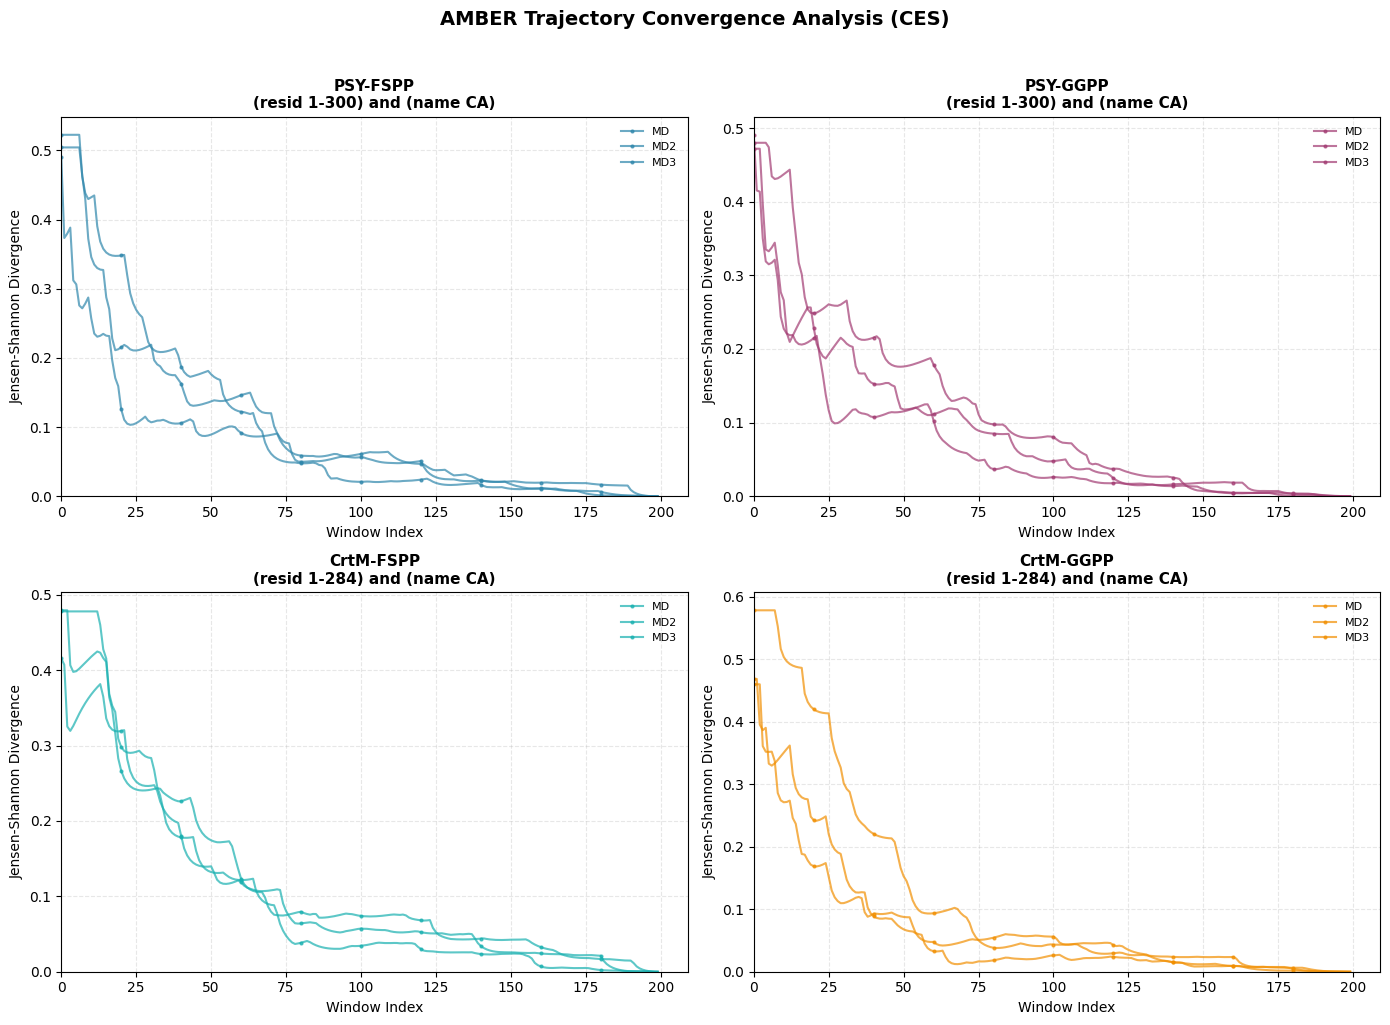

💾 Results saved to convergence_results.pkl


In [15]:
# Analysis parameters - ADJUST FOR YOUR DATA
WINDOW_SIZE = 50      # Frames per window
STRIDE = 2            # Subsample: analyze every Nth frame
N_CLUSTERS = 10       # KMeans clusters

print("🧬 Starting AMBER Multi-Replica Convergence Analysis")
print(f"Parameters: window={WINDOW_SIZE}, stride={STRIDE}, clusters={N_CLUSTERS}")

all_results = {}

for system_name, config in SYSTEMS.items():
    results = analyze_system_convergence(
        system_name=system_name,
        config=config,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        clustering_kwargs={'n_clusters': N_CLUSTERS}
    )
    if results['ces_data']:
        all_results[system_name] = results

if all_results:
    plot_all_systems_convergence(all_results, output_file="amber_convergence_summary.png")
    
    with open("convergence_results.pkl", "wb") as f:
        pickle.dump(all_results, f)
    print("💾 Results saved to convergence_results.pkl")
else:
    print("❌ No convergence data collected - check file paths and masks")

In [16]:
# %% [markdown]
# ## 🔍 Optional: Validate Setup Before Running

In [17]:
def validate_system_setup(system_name: str, config: dict):
    """Quick validation before running analysis."""
    print(f"\n🔍 Validating {system_name}...")
    root = Path(config['root_dir'])
    
    top_path = root / config['top_file']
    print(f"   Topology: {'✓' if top_path.exists() else '✗'} {top_path}")
    
    valid_replicas = 0
    for replica in config['replica_folders']:
        traj_path = root / replica / config['traj_filename']
        exists = traj_path.exists()
        print(f"   {replica}: {'✓' if exists else '✗'} {traj_path}")
        if exists:
            valid_replicas += 1
    
    mda_sel = amber_mask_to_mda(config['amber_ca_mask'])
    print(f"   AMBER mask: {config['amber_ca_mask']}")
    print(f"   → MDAnalysis: {mda_sel}")
    print(f"   Status: {valid_replicas}/{len(config['replica_folders'])} replicas found")
    return valid_replicas > 0

# Run validation
for name, cfg in SYSTEMS.items():
    validate_system_setup(name, cfg)


🔍 Validating PSY-FSPP...
   Topology: ✓ /media/dlbox/6TB/OPENFOLD/with_FPP2/run/MD/solvated.prmtop
   MD: ✓ /media/dlbox/6TB/OPENFOLD/with_FPP2/run/MD/MMPBSA/center2x.nc
   MD2: ✓ /media/dlbox/6TB/OPENFOLD/with_FPP2/run/MD2/MMPBSA/center2x.nc
   MD3: ✓ /media/dlbox/6TB/OPENFOLD/with_FPP2/run/MD3/MMPBSA/center2x.nc
   AMBER mask: :1-300@CA
   → MDAnalysis: (resid 1-300) and (name CA)
   Status: 3/3 replicas found

🔍 Validating PSY-GGPP...
   Topology: ✓ /media/dlbox/6TB/OPENFOLD/run/MD/solvated.prmtop
   MD: ✓ /media/dlbox/6TB/OPENFOLD/run/MD/MMPBSA/center2x.nc
   MD2: ✓ /media/dlbox/6TB/OPENFOLD/run/MD2/MMPBSA/center2x.nc
   MD3: ✓ /media/dlbox/6TB/OPENFOLD/run/MD3/MMPBSA/center2x.nc
   AMBER mask: :1-300@CA
   → MDAnalysis: (resid 1-300) and (name CA)
   Status: 3/3 replicas found

🔍 Validating CrtM-FSPP...
   Topology: ✓ /media/dlbox/8TB/New_simulation/PQR/3w7f/run/MD/solvated.prmtop
   MD: ✓ /media/dlbox/8TB/New_simulation/PQR/3w7f/run/MD/MMPBSA/center2x.nc
   MD2: ✓ /media/dlbox/8

---
## 📋 Interpretation Guide

| JSD Value | Interpretation |
|-----------|---------------|
| → 0.0 | Excellent convergence |
| < 0.1 | Good convergence |
| 0.1-0.3 | Moderate, may need more sampling |
| > 0.3 | Poor convergence, extend simulation |

**Tips**:
- Compare replica curves: similar shapes = reproducible sampling
- Plateau ≠ true convergence; check multiple metrics
- Combine with RMSD, Rg, or free energy analysis

---
*Created for AMBER MD analysis with MDAnalysis ENCORE*

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

def quick_plot_system(results: dict, system_name: str, smooth_window: int = 5):
    """Quick visualization of one system's convergence."""
    fig, ax = plt.subplots(figsize=(10, 6))
    color = results['config']['color']
    
    for ces_data, replica in zip(results['ces_data'], results['replica_names']):
        # Optional smoothing
        if smooth_window > 1:
            ces_plot = np.convolve(ces_data, np.ones(smooth_window)/smooth_window, mode='valid')
            x_plot = np.arange(len(ces_plot))
        else:
            ces_plot, x_plot = ces_data, np.arange(len(ces_data))
        
        ax.plot(x_plot, ces_plot, label=replica, color=color, alpha=0.8)
    
    ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='JSD=0.1 threshold')
    ax.set_xlabel('Window Index')
    ax.set_ylabel('Jensen-Shannon Divergence')
    ax.set_title(f'{system_name}: Convergence')
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
def extract_convergence_metrics(ces_data: np.ndarray, threshold: float = 0.1):
    """
    Extract quantitative convergence metrics from CES data.
    
    Returns:
        dict with final_value, plateau_window, below_threshold_frac
    """
    if len(ces_data) == 0:
        return None
    
    # Final 20% average (stability metric)
    final_frac = 0.2
    start_idx = int(len(ces_data) * (1 - final_frac))
    final_avg = np.mean(ces_data[start_idx:])
    final_std = np.std(ces_data[start_idx:])
    
    # First window below threshold
    below_thresh = np.where(ces_data < threshold)[0]
    first_below = below_thresh[0] if len(below_thresh) > 0 else None
    
    # Fraction of trajectory below threshold
    frac_below = np.mean(ces_data < threshold)
    
    return {
        'final_avg': final_avg,
        'final_std': final_std,
        'first_below_threshold': first_below,
        'fraction_below_threshold': frac_below,
        'total_windows': len(ces_data)
    }

In [20]:
# Extract metrics for reporting
for sys_name, sys_data in saved_results.items():
    print(f"\n{sys_name}:")
    for ces, rep in zip(sys_data['ces_data'], sys_data['replica_names']):
        metrics = extract_convergence_metrics(ces)
        if metrics:
            print(f"  {rep}: final_JSD={metrics['final_avg']:.3f}±{metrics['final_std']:.3f}, "
                  f"frac<0.1={metrics['fraction_below_threshold']:.1%}")

NameError: name 'saved_results' is not defined